# Building CAS Pipeline
This Notebook will be used as the basis to begin developing the script pipeline for measuring the assymetry of galaxies in the DESI sample.

In [1]:
from astropy.io import fits
from astropy.visualization import ImageNormalize, MinMaxInterval, SqrtStretch
from astropy.wcs import WCS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, Point
import cv2 as cv
from PIL import Image

from IPython.display import clear_output

import glob
import os
from tqdm import tqdm

So, the process will look like as follows:
    
    1. Find the Galaxy's center - minimizing the asymmetry measurement.
    2. Calculate the Asymmetry.
    3. Use the above galaxy center and estimated petrosian radius to calculate the Concentration.
    4. Calculate the Smoothness

## Importing the Data

In [2]:
df = pd.read_csv('C:/Users/oryan/Documents/mergers_in_desi/data/major-hec-manifest.csv', index_col = 0)

## Finding the Galaxy's Centre

### Getting Example Image

In [6]:
fits_folder = 'E:/GZ-DESI/images/major-dist'

In [7]:
fits_files = glob.glob(f'{fits_folder}/*.fits')

In [8]:
fits_file = fits_files[3]

In [9]:
with fits.open(fits_file) as hdul:
    header = hdul[0].header
    data = hdul[0].data[1,:,:]

In [10]:
norm = ImageNormalize(data, interval = MinMaxInterval(), stretch = SqrtStretch())

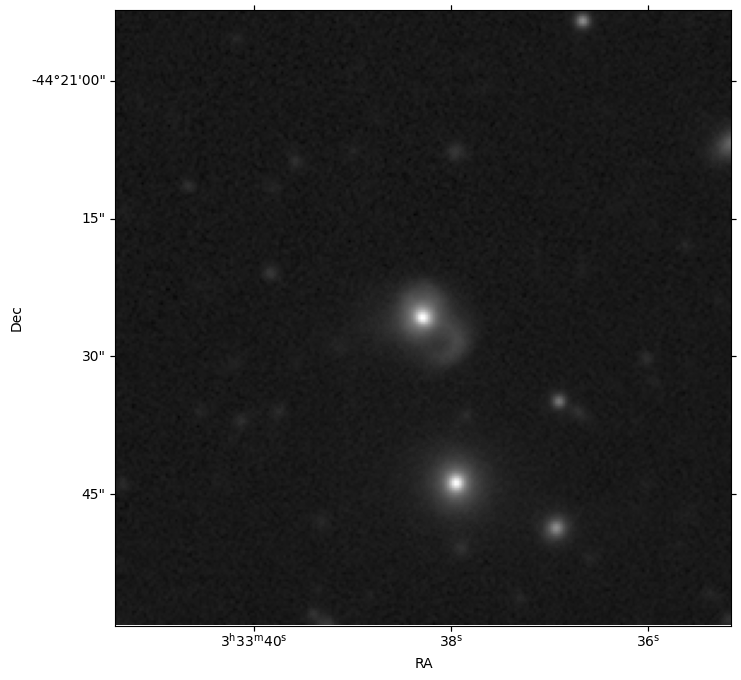

In [11]:
w = WCS(header, naxis = 2)

fig = plt.figure(figsize = (8,8))
ax1 = fig.add_subplot(111, projection = w)
ax1.imshow(data, cmap = 'gray', origin = 'lower', norm = norm)
ax1.set_xlabel('RA')
ax1.set_ylabel('Dec')
plt.show()

### Finding the Correct Contour

In [12]:
cutout_int = data.copy()
cut = np.percentile(data,80)
cutout_int[cutout_int <= cut] = 0
cutout_int[cutout_int > cut] = 1
cutout_int = cutout_int.astype(int)

In [13]:
def getting_correct_contours(contours, cen_x, cen_y):
    point = Point(cen_x, cen_y)        
    for i in contours:
        cont_arr = conts_to_arr(i)
        if len(cont_arr) > 2:
            polygon = Polygon(cont_arr)
            if polygon.contains(point):
                return cont_arr
            else:
                continue
        else:
            continue
        
    return 'failed'

In [14]:
def conts_to_arr(nested_list):
    contour_arr = np.zeros([len(nested_list),2])
    for i in range(len(nested_list)):
        row = nested_list[i][0]
        contour_arr[i,0] = row[0]
        contour_arr[i,1] = row[1]
    
    return contour_arr

In [15]:
contours, _ = cv.findContours(cutout_int, cv.RETR_FLOODFILL, cv.CHAIN_APPROX_NONE)
contour_arr = getting_correct_contours(contours, int(data.shape[0]/2), int(data.shape[1]/2))

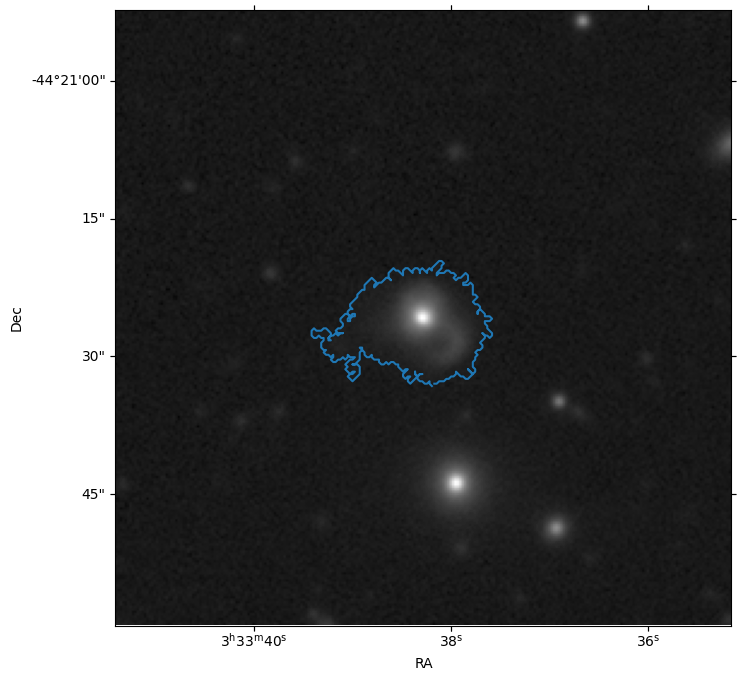

In [16]:
fig = plt.figure(figsize = (8,8))
ax1 = fig.add_subplot(111, projection = w)
ax1.imshow(data, cmap='gray', origin = 'lower', norm = norm)
ax1.plot(contour_arr[:,0], contour_arr[:,1])
ax1.set_xlabel('RA')
ax1.set_ylabel('Dec')
plt.show()

### Defining Galaxy and Non-Galaxy Pixels

In [17]:
pl = Polygon(contour_arr)

pixels_mask = np.zeros(data.shape).astype(bool)
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        pt = Point(i,j)
        if pl.contains(pt):
            pixels_mask[i,j] = True
pixels_mask = pixels_mask.T

In [18]:
gal_im = data.copy()
gal_im[~pixels_mask] = 0

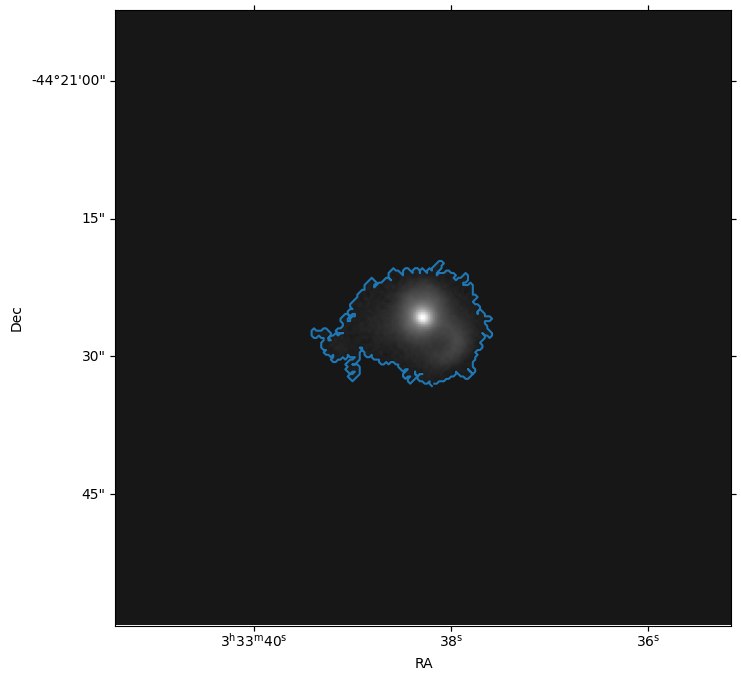

In [19]:
fig = plt.figure(figsize = (8,8))
ax1 = fig.add_subplot(111, projection = w)
ax1.imshow(gal_im, cmap='gray', origin = 'lower', norm = norm)
ax1.plot(contour_arr[:,0], contour_arr[:,1])
ax1.set_xlabel('RA')
ax1.set_ylabel('Dec')
plt.show()

### Calculating Asymmetry

In [20]:
gal_pixels_list = np.argwhere(pixels_mask).tolist()
gal_pixels_arr = np.asarray(gal_pixels_list)

In [21]:
tmp_centre = gal_pixels_arr[0]

In [22]:
im = Image.fromarray(gal_im)
rot_im = im.rotate(180, center = (tmp_centre[0], tmp_centre[1]))
gal_rot = np.array(rot_im)

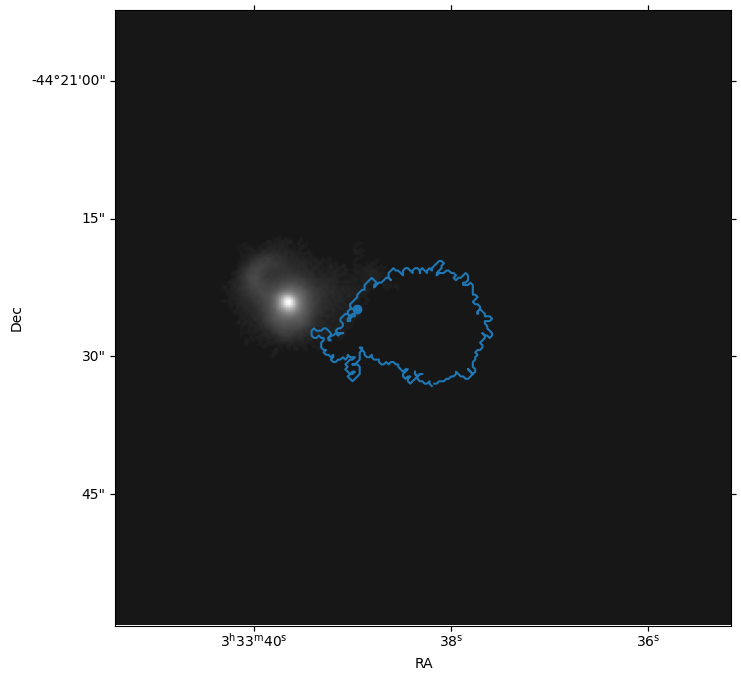

In [23]:
fig = plt.figure(figsize = (8,8))
ax1 = fig.add_subplot(111, projection = w)
ax1.imshow(gal_rot, cmap='gray', origin = 'lower', norm = norm)
ax1.plot(contour_arr[:,0], contour_arr[:,1])
ax1.scatter(tmp_centre[0], tmp_centre[1])
ax1.set_xlabel('RA')
ax1.set_ylabel('Dec')
plt.show()

In [24]:
%%time
min_A = np.inf
centre = np.array([0,0])

for i in gal_pixels_arr:
    im = Image.fromarray(gal_im)
    rot_im = im.rotate(180, center = (i[0], i[1]))
    gal_rot = np.array(rot_im)
    im.close()
    rot_im.close()
    
    gal_rot[~pixels_mask] = 0
    
    A = np.sum(abs(gal_im[pixels_mask] - gal_rot[pixels_mask])) / np.sum(abs(gal_im[pixels_mask]))
        
    if A < min_A:
        min_A = A
        centre = i

Wall time: 1.62 s


In [25]:
min_A

0.31874216

In [26]:
centre

array([128, 128])

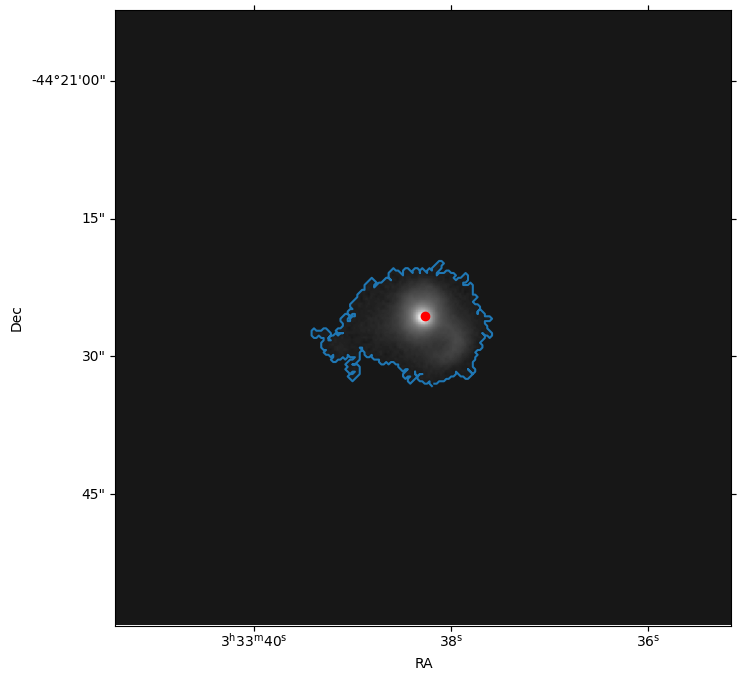

In [27]:
fig = plt.figure(figsize = (8,8))
ax1 = fig.add_subplot(111, projection = w)
ax1.imshow(gal_im, cmap='gray', origin = 'lower', norm = norm)
ax1.plot(contour_arr[:,0], contour_arr[:,1])
ax1.scatter(centre[0], centre[1], color = 'r')
ax1.set_xlabel('RA')
ax1.set_ylabel('Dec')
plt.show()

## Testing a Small Pipeline

In [147]:
def getting_correct_contours(contours, cen_x, cen_y):
    point = Point(cen_x, cen_y)        
    for i in contours:
        cont_arr = conts_to_arr(i)
        if len(cont_arr) > 2:
            polygon = Polygon(cont_arr)
            if polygon.contains(point):
                return cont_arr
            else:
                continue
        else:
            continue
        
    return 'failed'

In [148]:
def conts_to_arr(nested_list):
    contour_arr = np.zeros([len(nested_list),2])
    for i in range(len(nested_list)):
        row = nested_list[i][0]
        contour_arr[i,0] = row[0]
        contour_arr[i,1] = row[1]
    
    return contour_arr

In [149]:
def calc_a(im_path):
    ## Loading Data
    with fits.open(im_path) as hdul:
        header = hdul[0].header
        data = hdul[0].data[1,:,:]
    del hdul
    
    ## Finding Correct Contour
    cutout_int = data.copy()
    cut = np.percentile(data,80)
    cutout_int[cutout_int <= cut] = 0
    cutout_int[cutout_int > cut] = 1
    cutout_int = cutout_int.astype(int)
    
    contours, _ = cv.findContours(cutout_int, cv.RETR_FLOODFILL, cv.CHAIN_APPROX_NONE)
    contour_arr = getting_correct_contours(contours, int(data.shape[0]/2), int(data.shape[1]/2))
    
    ## Defining Non Galaxy Pixels
    pl = Polygon(contour_arr)

    pixels_mask = np.zeros(data.shape).astype(bool)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            pt = Point(i,j)
            if pl.contains(pt):
                pixels_mask[i,j] = True
    pixels_mask = pixels_mask.T
    
    gal_im = data.copy()
    gal_im[~pixels_mask] = 0
    
    gal_pixels_arr = np.asarray(np.argwhere(pixels_mask).tolist())
    
    min_A = np.inf
    centre = np.array([0,0])

    for i in gal_pixels_arr:
        im = Image.fromarray(gal_im)
        rot_im = im.rotate(180, center = (i[0], i[1]))
        gal_rot = np.array(rot_im)
        im.close()
        rot_im.close()

        gal_rot[~pixels_mask] = 0

        A = np.sum(abs(gal_im[pixels_mask] - gal_rot[pixels_mask])) / np.sum(abs(gal_im[pixels_mask]))

        if A < min_A:
            min_A = A
            centre = i
            
    return [min_A, centre]

In [150]:
a_dict = {os.path.basename(i).replace('-cutout.fits','') : calc_a(i) for i in tqdm(fits_files[:10])}

100%|██████████| 10/10 [02:33<00:00, 15.31s/it]


In [151]:
a_dict

{'100012_421': [0.3712969, array([128, 128])],
 '100025_3459': [0.24423376, array([128, 128])],
 '100049_651': [0.19087066, array([128, 128])],
 '100061_265': [0.31874216, array([128, 128])],
 '100108_3617': [0.7221607, array([156, 120])],
 '100121_1480': [0.7065878, array([128, 128])],
 '100137_317': [0.31695572, array([128, 128])],
 '100144_696': [0.22934149, array([128, 128])],
 '100784_196': [0.4614571, array([128, 128])],
 '100791_5616': [0.38336354, array([128, 128])]}

In [155]:
df_a = pd.DataFrame.from_dict(a_dict, orient = 'index').reset_index().rename(columns = {'index':'id_str', 0 : 'asym', 1 : 'centre'})

In [156]:
df_a

,id_str,asym,centre
0,100012_421,0.371297,"[128, 128]"
1,100025_3459,0.244234,"[128, 128]"
2,100049_651,0.190871,"[128, 128]"
3,100061_265,0.318742,"[128, 128]"
4,100108_3617,0.722161,"[156, 120]"
5,100121_1480,0.706588,"[128, 128]"
6,100137_317,0.316956,"[128, 128]"
7,100144_696,0.229341,"[128, 128]"
8,100784_196,0.461457,"[128, 128]"
9,100791_5616,0.383364,"[128, 128]"
